In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import c, pi
from astropy.constants import M_sun, G
from mpmath import hyp1f1

In [29]:
def F_amp(t, h, M_lens, y):

    # time scale
    Rs = 2 * G.value * M_lens / c**2                             # Schwarzchild radius
    tM = 2 * Rs / c                                             # time scale

    # Fourier transform of the unlensed signal h
    N = len(h)
    h_tilde = np.fft.fft(h)
    h_tilde_shifted = np.fft.fftshift(h_tilde)

    # frequency
    freqs = np.fft.fftfreq(N, d=t[1]-t[0])
    freqs_shifted = np.fft.fftshift(freqs)

    # angular frequency
    omega = freqs * 2 * pi
    omega_shifted = np.fft.fftshift(omega)

    # dimensionless frequency
    nu = omega * tM / 2 * pi
    nu_shifted = np.fft.fftshift(nu)

    # amplification factpr
    F = np.empty(N, dtype=complex)
    F[0] = 1.0 + 0.0j

    # index range parameter
    k_max = N // 2                                          # max index of half

    for k in range(1, k_max + 1):

        w = nu[k]

        if w <= 0:
            F[k] = 1.0 + 0.0j
            continue

        a = 1.0j * pi * w
        b = 1.0
        z = 1.0j * pi * w * y**2

        try:
            hyp = complex(hyp1f1(a,b,z))
        except Exception as exc:
            hyp = 1.0 + 0.0j

        A_num = 2 * pi**2 * w
        A_den = 1 - np.exp(-2 * pi**2 * w)

        A = np.sqrt(A_num/A_den)

        F[k] = A * hyp

    F_shifted = np.fft.fftshift(F)

    if N%2 == 0:
        F[k_max] = F[k_max].real + 0.0j

    for k in range(1, k_max + 1):
        F[-k] = np.conj(F[k])

    if np.any(np.isnan(F)):
        print("Warning: NaNs present in F; replacing with 1.0 + 0.0j")
        F = np.where(np.isnan(F), 1.0 + 0.0j, F)

    # lensed signal
    hL_shifted = h_tilde_shifted * F_shifted

    return nu_shifted, F_shifted, hL_shifted


In [52]:
# signal parameters
t = np.linspace(0,0.02,10000)
M_lens = 250 * M_sun.value
h0 = 1.0                                        # maximum amplitude
nu0 = 5/4                                       # Fresnel number
y = 0.1                                         # source position
M_source = 0.24 * M_lens / nu0
f0 = 1.207*10**(4)*(M_sun.value/M_source)
Gamma = 1.496 * f0
omega0 = 2*pi*f0
h = h0 * np.exp(-Gamma*t)*np.cos(omega0*t)

In [ ]:
nu_shifted, F_shifted, hL_shifted = F_amp(t=t, h=h, M_lens=M_lens, y=y)

(0.0, 0.5)

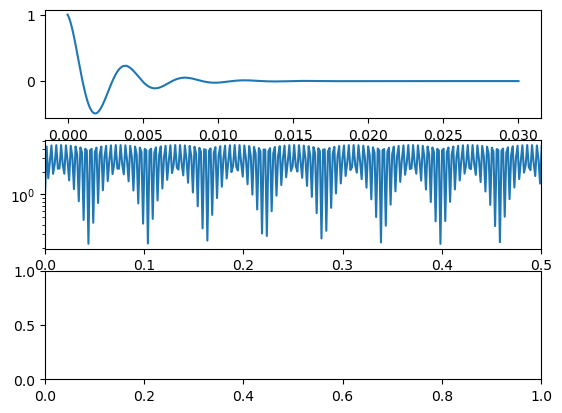

In [ ]:
fig, ax = plt.subplots(nrows=3)

ax[0].plot(t,h)

ax[1].plot(nu_shifted[len(nu_shifted)//2:]/10**3, np.abs(F_shifted[len(nu_shifted)//2:]))
ax[1].set_yscale('log')
ax[1].set_xlim([0,0.5])

ax[2].plot(nu_shifted, )